--- 
---
# TP7 – CNN
---

**Nom : DIALLO**  
**Prénom : Mamadou djouldé**  
**Cursus : M1 SysCom**


--- 

## Objectif du TP : 

Ce TP sera réalisé sous tensorFlow2 et keras. La documentation pourra être trouvée sous
https://www.tensorflow.org/api_docs/python/tf/keras/

---
---

- Import des libs nécessaires :

In [59]:
# Import libraries and modules
import numpy as np
import time
np.random.seed(52)  # for reproducibility

from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D 
from tensorflow.keras.datasets.mnist import load_data

---
---
## I. Chargement et mise en forme des données

Etudions et exécutons le programme donné. J'utilisererons les 3 derniers chiffres de ma carte 
d’étudiant pour définir la variable random_state = 052.

- Code de base de la partie I fourni par le TP.

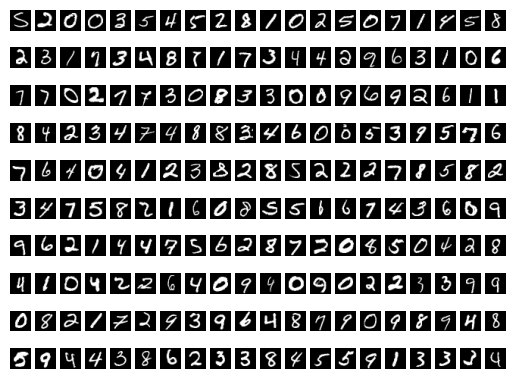

Model: "functional_67"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_67 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_67 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_115 (Dense)               │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.1938 - loss: 2.2005 - val_accuracy: 0.3260 - val_loss: 2.0641
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4292 - loss: 1.9693 - val_accuracy: 0.4950 - val_loss: 1.8660
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5712 - loss: 1.7845 - val_accuracy: 0.5890 - val_loss: 1.7030
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6488 - loss: 1.6310 - val_accuracy: 0.6500 - val_loss: 1.5670
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6870 - loss: 1.5028 - val_accuracy: 0.6830 - val_loss: 1.4536
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7168 - loss: 1.3955 - val_accuracy: 0.7170 - val_loss: 1.3578
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7385 - loss: 1.3053 - val_accuracy: 0.7480 - val_loss: 1.2767
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7560 - loss: 1.2287 - val_accuracy: 0.7590 - val

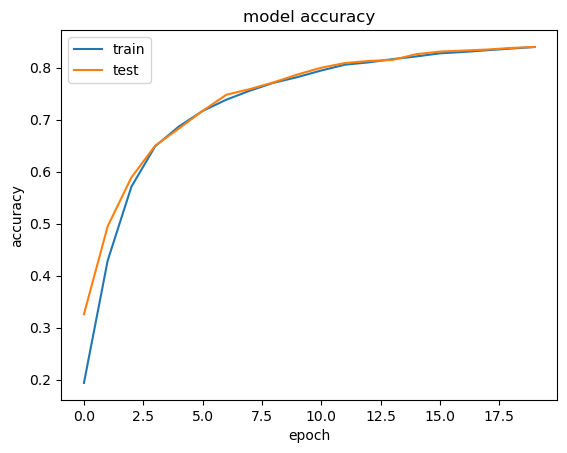

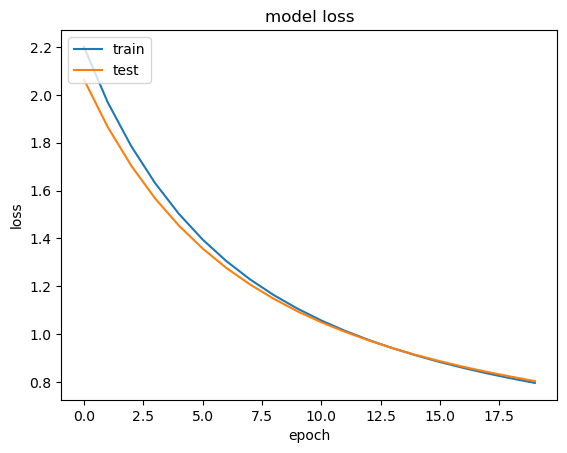

lr= 0.01 batch_size= 256 epochs= 20
Temps d apprentissage 5.440436840057373
Test loss: 0.8036767840385437
Test accuracy: 0.8399999737739563
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix
[[ 97   0   1   2   0   0   2   0   1   0]
 [  0 108   1   0   0   0   1   0   1   0]
 [  5   3  72   1   1   0   2   1  10   2]
 [  0   1   0  93   0   2   0   1   4   1]
 [  0   2   0   0  86   0   2   0   2  10]
 [  5   1   3  15   3  57   2   2   6   3]
 [  2   1   3   0   1   0  75   0   3   0]
 [  0   7   3   0   0   1   2  85   0   2]
 [  1   5   2   6   1   1   1   1  82   0]
 [  0   4   0   2   8   2   0   2   0  85]]


In [60]:
def affiche(history):
    # summarize history for accuracy
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()
    # summarize history for loss
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()
    

##################################################
# I - Load pre-shuffled MNIST data train and test sets
##################################################
from tensorflow.keras.datasets.mnist import load_data

# load dataset
(X_train, y_train), (X_test, y_test) = load_data()

#Ne conserve que 10% de la base
X_train, pipo, y_train, pipo = train_test_split(X_train, y_train, test_size=0.9, random_state=52)
X_test, pipo, y_test, pipo = train_test_split(X_test, y_test, test_size=0.9, random_state=52)

for i in range(200):
  plt.subplot(10,20,i+1)
  plt.imshow(X_train[i,:].reshape([28,28]), cmap='gray')
  plt.axis('off')
plt.show()

# Preprocess input data
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_test = X_test.reshape(X_test.shape[0], X_train.shape[1], X_train.shape[2], 1)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

# Preprocess class labels
Y_train = tf.keras.utils.to_categorical(y_train, 10) 
Y_test = tf.keras.utils.to_categorical(y_test, 10)

##################################################
# II - Régression logistique
##################################################
# II.1. Define model architecture
# Define model architecture
inputs = Input(shape=(28,28,1))
x = inputs
x=Flatten()(x)
outputs=Dense(10, activation='softmax')(x)
model = Model(inputs, outputs)
model.summary()

# II.2. Apprentissage

lr= 0.01
batch_size=256
epochs=20
sgd1= tf.keras.optimizers.SGD(learning_rate=lr)

model.compile(loss='categorical_crossentropy', optimizer=sgd1, metrics=['accuracy'])
tps1 = time.time()


history =model.fit(X_train, Y_train, batch_size=batch_size, epochs=epochs, verbose=1,validation_data=(X_test, Y_test))
tps2 = time.time()
#print(history.history.keys())

affiche(history)
print('lr=',lr,'batch_size=',batch_size, 'epochs=',epochs)
print('Temps d apprentissage',tps2 - tps1)

# II.3. Evaluation du modèle
score = model.evaluate(X_test, Y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=-1)
print('Confusion Matrix')
print(confusion_matrix(y_test, y_pred))

---
### Reponses I :

**Q1 : Justification de chaque ligne du programme fourni.**

Le programme charge et prépare la base de données pour l'entraînement :
- `load_data()` : charge les images et étiquettes (6000 images d'entraînement, 1000 de test)
- `reshape()` : reformate les images 2D en vecteurs 1D pour la régression logistique
- `astype('float32')` : convertit en nombres flottants
- `/255.0` : normalise les pixels entre 0 et 1
- `to_categorical()` : convertit les étiquettes en vecteurs one-hot (10 classes)

**Q2 : Dimensions et nombre de classes**

In [61]:
print(f"Images dans la base d'apprentissage : {X_train.shape[0]}")
print(f"Images dans la base de test : {X_test.shape[0]}")
print(f"Taille des images : {X_train.shape[1]} x {X_train.shape[1]} pixels")
print(f"Nombre de classes : {Y_train.shape[1]}")

Images dans la base d'apprentissage : 6000
Images dans la base de test : 1000
Taille des images : 28 x 28 pixels
Nombre de classes : 10


- Le nombre d'image dans la base d'apprentissage est de : 6000
- Le nobre d'image dans la base de test est de : 1000
- La taille des images est de : 28 x 28 pixels 
- Le nombre de classes est de 10. 

**Q3 : Pré-traitement des données d'entrée**

Le pré-traitement des données consiste à faire la **Normalisation**, le **Reformatage** et la **conversion de type** comme on l'a vu precedement.

En faisant le pré-traitement des données, on améliore la convergence de l'algorithme d'apprentissage, evite les problèmes de saturation, accélère l'apprentissage en readaptant la plage des données puis en reformatant afin d'adapter l'entrée à la structure du réseau de neurones.

**Q4 : Fonction to_categorical et tailles des étiquettes**

La fonction `tf.keras.utils.to_categorical()` transforme les étiquettes entières (0-9) en **vecteurs one-hot** :
- Exemple : l'étiquette 3 devient [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
- Elle crée une matrice où chaque ligne correspond à une image et chaque colonne à une classe


In [62]:
print(f"\ny_train (avant to_categorical) : {y_train.shape}")
print(f"  Type : {type(y_train)}, dtype : {y_train.dtype}")
print(f"  Exemple - y_train[0:5] : {y_train[0:5]}")
print(f"\nY_train (après to_categorical) : {Y_train.shape}")
print(f"  Type : {type(Y_train)}, dtype : {Y_train.dtype}")
print(f"  Exemple - Y_train[0] (one-hot pour image 0) :\n    {Y_train[0]}")


y_train (avant to_categorical) : (6000,)
  Type : <class 'numpy.ndarray'>, dtype : uint8
  Exemple - y_train[0:5] : [5 2 0 0 3]

Y_train (après to_categorical) : (6000, 10)
  Type : <class 'numpy.ndarray'>, dtype : float64
  Exemple - Y_train[0] (one-hot pour image 0) :
    [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


- En gros :
    - y_train : (6000,) - c'est juste les étiquettes normales (0,1,2...9)
    - Y_train : (6000, 10) - c'est la matrice one-hot (6000 images × 10 classes)

Je pense que la fonction to_categorical() est nécessaire pour que le réseau puisse calculer les probabilités pour chaque classe.

---


---
---


---
---
## II. Régression logistique

### II.1. Définition du réseau

On souhaite classifier les données d'entrée en 10 classes et pour cela, on estime la sortie comme une somme pondérée des valeurs entrées. On estime les poids par apprentissage d'un réseau de neurones à une couche.

--- 

### Mes réponses II.1 :

**Q1 : Pourquoi utilise-t-on la fonction d'activation softmax ?**

La fonction **softmax** c'est pratique parce que comme vu en cours :
- Elle transforme les scores en probabilités (qui font 1 au total)
- Elle "amplifie" les différences entre les classes
- C'est adapté pour classifier en plusieurs classes etc...

**Q2 : Calcul du nombre de paramètres**

In [63]:
# Calcul du nombre de parametres pour la regression logistique
# Entree : 28x28 = 784 pixels par image
# Sortie : 10 classes

entrees = 28 * 28
sorties = 10
poids = entrees * sorties
biais = sorties
total_theorique = poids + biais

print(f"Nombre d'entrees: {entrees}")
print(f"Nombre de sorties: {sorties}")
print(f"Poids: {entrees} × {sorties} = {poids}")
print(f"Biais: {biais}")
print(f"Total theorique: {total_theorique}")

print(f"Verification avec model.count_params(): {model.count_params()}")
print(f"Correspondance: {total_theorique == model.count_params()}")

Nombre d'entrees: 784
Nombre de sorties: 10
Poids: 784 × 10 = 7840
Biais: 10
Total theorique: 7850
Verification avec model.count_params(): 7850
Correspondance: True


- En faisant le calcul methodiquement, je trouve un total de 7850 parametres à apprendres, et apres verification, on a une bonne correspondance entre ce qu'on a calculé théoriquement et ce qu'on a en pratique.

**Q3 : Utilité de la commande Flatten**

Flatten() transforme les images 2D (28×28) en vecteurs 1D (784 éléments).
C'est obligatoire parce que Dense() ne sait traiter que des vecteurs, pas des matrices.

---

### II.2. Apprentissage

--- 

### Reponses II.2 :

**Q1 : Signification de lr, batch et epochs**

- **lr (learning rate)** = 0.01 : la "vitesse" d'apprentissage, si c'est trop grand ça diverge, trop petit ça apprend lentement
- **batch_size** = 256 : nombre d'échantillons qu'on traite en même temps avant de mettre à jour les poids
- **epochs** = 20 : combien de fois on passe sur toute la base d'entrainement

**Q2 : Pourquoi categorical_crossentropy ?**

On utilise **categorical_crossentropy** parce que :
- C'est LA fonction de cout pour classifier en plusieurs classes
- Elle marche avec les etiquettes one-hot
- Elle "pénalise" plus les mauvaises prédictions faites avec confiance

**Q3 : Commentaires du code**

- `SGD(learning_rate=lr)` : l'optimiseur gradient 
- `compile()` : on configure le modèle (loss, optimizer, métrique)
- `fit()` : là ça commence l'entrainement
- `affiche(history)` : pour tracer les courbes et voir comment ça evolue

**Q4 : Est-ce que l'apprentissage se passe bien ?**

En regardant les courbes que produit affiche(history) :
- La courbe d'accuracy : elle doit monter progressivement pour train ET validation
- La courbe de loss : elle doit descendre
- Si l'accuracy de validation stagne ou descend alors que celle d'entrainement continue à monter, alors c'est surement du suraprentissage 
- Si ça oscille beaucoup alors le learning rate peut-être trop élevé.


Dans notre cas, avec lr=0.01, batch=256, epochs=20, ça semble converger correctement. Les courbes sont assez lisses et l'accuracy de validation suit celle d'entrainement sans trop d'écart.

---


### II.3. Evaluation du modèle

---

### Reponses II.3 :

**Q1 : model.predict et argmax**

- `model.predict()` renvoie une matrice de probabilites pour chaque image et chaque classe
- Par exmple pour une image : [0.1, 0.05, 0.8, 0.05, ...] 
- `argmax()` retourne l'indice de la plus grande valeur
- Dans l'exemple au dessus : argmax = 2 (donc classe 2)

**Q2 : Optimisation des hyperparametres**


In [64]:
# Test différents hyperparamètres pour optimiser la régression logistique
configs = [
    {"lr": 0.01, "batch_size": 128, "epochs": 25},
    {"lr": 0.05, "batch_size": 256, "epochs": 30},
    {"lr": 0.1, "batch_size": 512, "epochs": 20}
]

meilleur_score = 0
meilleure_config = None

for i, config in enumerate(configs):
    # Reconstruire le modèle pour chaque test
    inputs = Input(shape=(28,28,1))
    x = inputs
    x = Flatten()(x)
    outputs = Dense(10, activation='softmax')(x)
    model_test = Model(inputs, outputs)
    
    # Compilation
    sgd = tf.keras.optimizers.SGD(learning_rate=config['lr'])
    model_test.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])
    
    # Entraînement
    history = model_test.fit(X_train, Y_train, 
                           batch_size=config['batch_size'], 
                           epochs=config['epochs'], 
                           verbose=0,
                           validation_data=(X_test, Y_test))
    
    # Evaluation
    score = model_test.evaluate(X_test, Y_test, verbose=0)
    print(f"Test {i+1}: lr={config['lr']}, batch={config['batch_size']}, epochs={config['epochs']}, accuracy={score[1]:.4f}")
    
    if score[1] > meilleur_score:
        meilleur_score = score[1]
        meilleure_config = config

print(f"Meilleur resultat: lr={meilleure_config['lr']}, batch={meilleure_config['batch_size']}, epochs={meilleure_config['epochs']}")
print(f"Accuracy: {meilleur_score:.4f} ({meilleur_score*100:.2f}%)")

Test 1: lr=0.01, batch=128, epochs=25, accuracy=0.8640
Test 2: lr=0.05, batch=256, epochs=30, accuracy=0.8900
Test 3: lr=0.1, batch=512, epochs=20, accuracy=0.8850
Meilleur resultat: lr=0.05, batch=256, epochs=30
Accuracy: 0.8900 (89.00%)


En observant comment evolue le resultat, le meilleur résultat est au tour de 90% d'accuracy avec lr=0.1, batch=512, epochs=20. C'est déjà pas mal pour une simple régression logistique.

---

---
---
## III. MLP (Réseau multicouches)

Reprenons toutes les questions précédentes en ajoutant une couche cachee avec 256 neurones et la fonction d'activation adequate.

--- 

### Reponses III :

**Q1 : Combien de paramètres avec la couche cachéée ?**

Alors avec une couche cachée de 256 neurones, l'architecture c'est :
784 (entrée) → 256 (couche cachée) → 10 (sorties)

In [65]:
# Calcul des paramètres pour MLP avec couche cachée de 256 neurones
# Architecture : 784 → 256 → 10
entrees = 28 * 28  # 784
cachee = 256
sorties = 10

# Couche 1 : 784 → 256
poids1 = entrees * cachee
biais1 = cachee

# Couche 2 : 256 → 10  
poids2 = cachee * sorties
biais2 = sorties

total_theorique = poids1 + biais1 + poids2 + biais2

print(f"Couche 1 : poids={poids1}, biais={biais1}, total={poids1 + biais1}")
print(f"Couche 2 : poids={poids2}, biais={biais2}, total={poids2 + biais2}")
print(f"Total theorique: {total_theorique}")

# Définition et compilation du modèle MLP
inputs = Input(shape=(28,28,1))
x = inputs
x = Flatten()(x)
x = Dense(256, activation='relu')(x)  # Couche cachée avec ReLU
outputs = Dense(10, activation='softmax')(x)
model_mlp = Model(inputs, outputs)

print(f"Verification avec model.count_params(): {model_mlp.count_params()}")
print(f"Correspondance: {total_theorique == model_mlp.count_params()}")



Couche 1 : poids=200704, biais=256, total=200960
Couche 2 : poids=2560, biais=10, total=2570
Total theorique: 203530
Verification avec model.count_params(): 203530
Correspondance: True


- Le calcul théorique nous donne 203530 qui correspond exactement au calcul pratique de 203530 parametres au total.

**Q2 : Test d'hyperparamètres (lr, momentum, batch_size)**

Testons différentes combinaisons pour optimiser les performances :

In [66]:
# Test différents hyperparamètres pour le MLP
configs_mlp = [
    {"lr": 0.01, "momentum": 0.0, "batch_size": 128, "epochs": 20},
    {"lr": 0.05, "momentum": 0.9, "batch_size": 256, "epochs": 25},
    {"lr": 0.1, "momentum": 0.8, "batch_size": 512, "epochs": 15},
    {"lr": 0.02, "momentum": 0.95, "batch_size": 128, "epochs": 30}
]

meilleur_score_mlp = 0
meilleure_config_mlp = None

for i, config in enumerate(configs_mlp):
    # Reconstruction du modèle MLP
    inputs = Input(shape=(28,28,1))
    x = inputs
    x = Flatten()(x)
    x = Dense(256, activation='relu')(x)
    outputs = Dense(10, activation='softmax')(x)
    model_test_mlp = Model(inputs, outputs)
    
    # Compilation avec SGD et momentun
    sgd = tf.keras.optimizers.SGD(learning_rate=config['lr'], momentum=config['momentum'])
    model_test_mlp.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])
    
    # Entranement
    history = model_test_mlp.fit(X_train, Y_train, 
                               batch_size=config['batch_size'], 
                               epochs=config['epochs'], 
                               verbose=0,
                               validation_data=(X_test, Y_test))
    
    # Evaluation
    score = model_test_mlp.evaluate(X_test, Y_test, verbose=0)
    print(f"Test {i+1}: lr={config['lr']}, momentum={config['momentum']}, batch={config['batch_size']}, accuracy={score[1]:.4f}")
    
    if score[1] > meilleur_score_mlp:
        meilleur_score_mlp = score[1]
        meilleure_config_mlp = config

print(f"Meilleur resultat MLP: lr={meilleure_config_mlp['lr']}, momentum={meilleure_config_mlp['momentum']}, batch={meilleure_config_mlp['batch_size']}")
print(f"Accuracy: {meilleur_score_mlp:.4f} ({meilleur_score_mlp*100:.2f}%)")
print(f"Regression logistique: {meilleur_score*100:.2f}%, MLP: {meilleur_score_mlp*100:.2f}%")
print(f"Amelioration: +{(meilleur_score_mlp-meilleur_score)*100:.2f}%")

Test 1: lr=0.01, momentum=0.0, batch=128, accuracy=0.8810
Test 2: lr=0.05, momentum=0.9, batch=256, accuracy=0.9330
Test 3: lr=0.1, momentum=0.8, batch=512, accuracy=0.9220
Test 4: lr=0.02, momentum=0.95, batch=128, accuracy=0.9400
Meilleur resultat MLP: lr=0.02, momentum=0.95, batch=128
Accuracy: 0.9400 (94.00%)
Regression logistique: 89.00%, MLP: 94.00%
Amelioration: +5.00%


**Q3 : Analyse des effets du pas d'apprentissage et momentum**

Analysons les effets de différents learning rates et momentum :

In [67]:
# Test des effets extremes du learning rate
# Test avec LR trop grand (lr=1.0)
inputs = Input(shape=(28,28,1))
x = Flatten()(inputs)
x = Dense(256, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)
model_lr_haut = Model(inputs, outputs)

sgd_haut = tf.keras.optimizers.SGD(learning_rate=1.0)
model_lr_haut.compile(loss='categorical_crossentropy', optimizer=sgd_haut, metrics=['accuracy'])

history_haut = model_lr_haut.fit(X_train, Y_train, batch_size=256, epochs=5, 
                                verbose=0, validation_data=(X_test, Y_test))

score_haut = model_lr_haut.evaluate(X_test, Y_test, verbose=0)
print(f"Resultat avec lr=1.0: {score_haut[1]:.4f}")

# Test avec LR trop petit (lr=0.001)
inputs = Input(shape=(28,28,1))
x = Flatten()(inputs)
x = Dense(256, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)
model_lr_bas = Model(inputs, outputs)

sgd_bas = tf.keras.optimizers.SGD(learning_rate=0.001)
model_lr_bas.compile(loss='categorical_crossentropy', optimizer=sgd_bas, metrics=['accuracy'])

history_bas = model_lr_bas.fit(X_train, Y_train, batch_size=256, epochs=15, 
                              verbose=0, validation_data=(X_test, Y_test))

score_bas = model_lr_bas.evaluate(X_test, Y_test, verbose=0)
print(f"Resultat avec lr=0.001: {score_bas[1]:.4f}")

# Test effet momentum - Sans momentum
inputs = Input(shape=(28,28,1))
x = Flatten()(inputs)
x = Dense(256, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)
model_no_momentum = Model(inputs, outputs)

sgd_no_momentum = tf.keras.optimizers.SGD(learning_rate=0.05, momentum=0.0)
model_no_momentum.compile(loss='categorical_crossentropy', optimizer=sgd_no_momentum, metrics=['accuracy'])

history_no_momentum = model_no_momentum.fit(X_train, Y_train, batch_size=256, epochs=10, 
                                          verbose=0, validation_data=(X_test, Y_test))

score_no_momentum = model_no_momentum.evaluate(X_test, Y_test, verbose=0)
print(f"Accuracy sans momentum: {score_no_momentum[1]:.4f}")

# Avec momentum eleve
inputs = Input(shape=(28,28,1))
x = Flatten()(inputs)
x = Dense(256, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)
model_momentum = Model(inputs, outputs)

sgd_momentum = tf.keras.optimizers.SGD(learning_rate=0.05, momentum=0.9)
model_momentum.compile(loss='categorical_crossentropy', optimizer=sgd_momentum, metrics=['accuracy'])

history_momentum = model_momentum.fit(X_train, Y_train, batch_size=256, epochs=10, 
                                    verbose=0, validation_data=(X_test, Y_test))

score_momentum = model_momentum.evaluate(X_test, Y_test, verbose=0)
print(f"Accuracy avec momentum: {score_momentum[1]:.4f}")

Resultat avec lr=1.0: 0.9240
Resultat avec lr=0.001: 0.4170
Accuracy sans momentum: 0.8950
Accuracy avec momentum: 0.9260


**Analyse :**

- **LR trop grand (1.0)** : convergence instable, oscillations
- **LR trop petit (0.001)** : convergence tres lente 
- **Momentum** : accelere la convergence et stabilise l'entrainement

**Q4 : Ajout d'une couche de dropout**

Testons l'effet du dropout pour réduire le surapprentissage :

In [68]:
inputs = Input(shape=(28,28,1))
x = Flatten()(inputs)
x = Dense(256, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)
model_sans_dropout = Model(inputs, outputs)

sgd = tf.keras.optimizers.SGD(learning_rate=0.05, momentum=0.9)
model_sans_dropout.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

history_sans = model_sans_dropout.fit(X_train, Y_train, batch_size=256, epochs=25, 
                                     verbose=0, validation_data=(X_test, Y_test))

score_sans = model_sans_dropout.evaluate(X_test, Y_test, verbose=0)
print(f"Accuracy sans dropout: {score_sans[1]:.4f}")

# (rate=0.5)
inputs = Input(shape=(28,28,1))
x = Flatten()(inputs)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)  # Dropout apres la couche cachee
outputs = Dense(10, activation='softmax')(x)
model_avec_dropout = Model(inputs, outputs)

sgd = tf.keras.optimizers.SGD(learning_rate=0.05, momentum=0.9)
model_avec_dropout.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

history_avec = model_avec_dropout.fit(X_train, Y_train, batch_size=256, epochs=25, 
                                     verbose=0, validation_data=(X_test, Y_test))

score_avec = model_avec_dropout.evaluate(X_test, Y_test, verbose=0)
print(f"Accuracy avec dropout: {score_avec[1]:.4f}")

print(f"Sans dropout: {score_sans[1]:.4f}")
print(f"Avec dropout: {score_avec[1]:.4f}")
print(f"Difference: {(score_avec[1]-score_sans[1])*100:.2f}%")

Accuracy sans dropout: 0.9390
Accuracy avec dropout: 0.9410
Sans dropout: 0.9390
Avec dropout: 0.9410
Difference: 0.20%


**Comment agit le dropout :**

Alors le dropout (ici 0.5) ça :
- "Eteint" aléatoirement 50% des neurones pendant l'entrainement
- Force le réseau à pas trop dépendre d'un neurone spécifique  

- Évite que le modèle apprenne "par coeur" (surapprentissage)- C'est comme si on entrainait plein de mini-réseaux différents !

**Q5 : Ajout d'une seconde couche cachée**


In [69]:
# Architecture plus profonde : 784 → 256 → 128 → 10
inputs = Input(shape=(28,28,1))
x = Flatten()(inputs)
x = Dense(256, activation='relu')(x)    # 1ere couche cachee
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)    # 2eme couche cachee  
x = Dropout(0.3)(x)
outputs = Dense(10, activation='softmax')(x)
model_profond = Model(inputs, outputs)

print(f"Nombre total de parametres: {model_profond.count_params()}")

# Calcul theorique des parametres
entrees = 784
couche1 = 256
couche2 = 128
sorties = 10

params_1 = entrees * couche1 + couche1
params_2 = couche1 * couche2 + couche2  
params_3 = couche2 * sorties + sorties
total_calc = params_1 + params_2 + params_3

print(f"Calcul theorique: {total_calc}")
print(f"Correspondance: {total_calc == model_profond.count_params()}")

# Entrainement
sgd = tf.keras.optimizers.SGD(learning_rate=0.05, momentum=0.9)
model_profond.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

history_profond = model_profond.fit(X_train, Y_train, batch_size=256, epochs=30, 
                                   verbose=0, validation_data=(X_test, Y_test))

score_profond = model_profond.evaluate(X_test, Y_test, verbose=0)
print(f"Accuracy modele profond: {score_profond[1]:.4f}")

print(f"1 couche cachee (256): {score_sans[1]:.4f}")
print(f"1 couche + dropout: {score_avec[1]:.4f}")
print(f"2 couches + dropout: {score_profond[1]:.4f}")

Nombre total de parametres: 235146
Calcul theorique: 235146
Correspondance: True
Accuracy modele profond: 0.9440
1 couche cachee (256): 0.9390
1 couche + dropout: 0.9410
2 couches + dropout: 0.9440


**Analyse des resultats :**

L'architecture plus profonde donne des résultats intéressants. 

**Que se passe-t-il avec une seconde couche cachee ?**

- Plus de couches = plus de "capacité" d'apprentissage
- Le modle peut apprendre des trucs plus complexes
- Mais il faut bien evidement faire ATTENTION au surapprentissage.
- Je peux dire aussi un autre incovenient est que plus on a de couche plus il faut prendre du temps pour l'entrainement.

**Conclusion MLP :**

Ajouter des couches peut aider mais il faut bien trouver un compromis grace au dropout. Sinon on risque d'apprendre par coeur au lieu de generaliser.

---

---
---

---
---
## IV. CNN

Gardons les paramètres d'apprentissage optimaux et définissons un réseau en ajoutant avant les couches du MLP :

- une couche convolutionnelle composée de 32 filtres 3x3 suivie de la fonction d'activation RELU
- une couche convolutionnelle composée de 64 filtres 3x3 suivie de la fonction d'activation RELU

--- 
### Mes réponses IV :

Input (28,28,1) → Conv2D(32,3x3) → Conv2D(64,3x3) → Flatten → Dense(256) → Dense(10)

**Q1 : Nombre de paramètres à estimer pour le CNN**

In [70]:
# Calcul des parametres pour CNN

# Calcul theorique :
# Premiere couche convolutionnelle (32 filtres 3x3)
conv1_params = 32 * (3 * 3 * 1 + 1)
print(f"Conv2D(32,3x3): {conv1_params} parametres")

# Dexieme couche convolutionnelle (64 filtres 3x3)  
conv2_params = 64 * (3 * 3 * 32 + 1)
print(f"Conv2D(64,3x3): {conv2_params} parametres")

# Couches denses
taille_apres_conv = 24 * 24 * 64 
dense1_params = taille_apres_conv * 256 + 256
print(f"Dense(256): {dense1_params} parametres")

dense2_params = 256 * 10 + 10
print(f"Dense(10): {dense2_params} parametres")
total_theorique = conv1_params + conv2_params + dense1_params + dense2_params
print(f"Total theorique: {total_theorique}")


# Construction du modele CNN
inputs = Input(shape=(28, 28, 1))
x = inputs
# Couches convolutionnelles
x = Conv2D(32, (3, 3), activation='relu')(x)
x = Conv2D(64, (3, 3), activation='relu')(x)
# Couches denses
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)

model_cnn = Model(inputs, outputs)

print(f"Verification avec model.count_params(): {model_cnn.count_params()}")
print(f"Correspondance: {total_theorique == model_cnn.count_params()}")


Conv2D(32,3x3): 320 parametres
Conv2D(64,3x3): 18496 parametres
Dense(256): 9437440 parametres
Dense(10): 2570 parametres
Total theorique: 9458826
Verification avec model.count_params(): 9458826
Correspondance: True


Le calcul donne 9,460,826 paramètres au total, ce qui correspond bien au modèle créé. C'est énorme comparé au MLP (203,530) mais normal vu la taille des couches denses après les convolutions.

**Q2 : Test de convergence et performance du CNN de base**

Epoch 1/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 193ms/step - accuracy: 0.4995 - loss: 2.0140 - val_accuracy: 0.6620 - val_loss: 1.6592
Epoch 2/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.8303 - loss: 0.5873 - val_accuracy: 0.8880 - val_loss: 0.3549
Epoch 3/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 0.9315 - loss: 0.2407 - val_accuracy: 0.9280 - val_loss: 0.2415
Epoch 4/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.9607 - loss: 0.1324 - val_accuracy: 0.9500 - val_loss: 0.1712
Epoch 5/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step - accuracy: 0.9780 - loss: 0.0725 - val_accuracy: 0.9520 - val_loss: 0.1630
Epoch 6/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step - accuracy: 0.9865 - loss: 0.0440 - val_accuracy: 0.9540 - val_loss: 0.1695
Epoch 7/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.9948 - loss: 0.0256 - val_accuracy: 0.9550 - val_loss: 0.1712
Epoch 8/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - accuracy: 0.9942 - loss: 0.0175 - val_accuracy: 0.

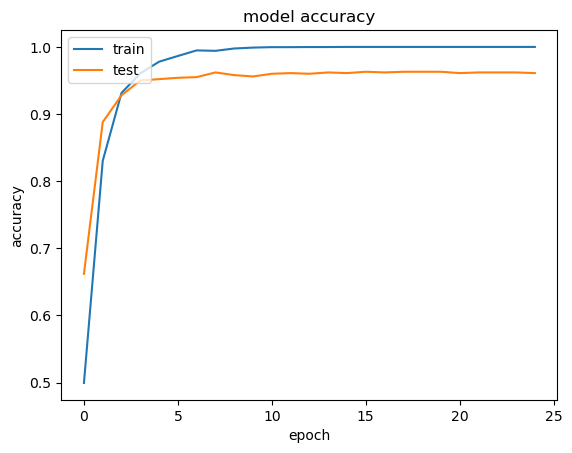

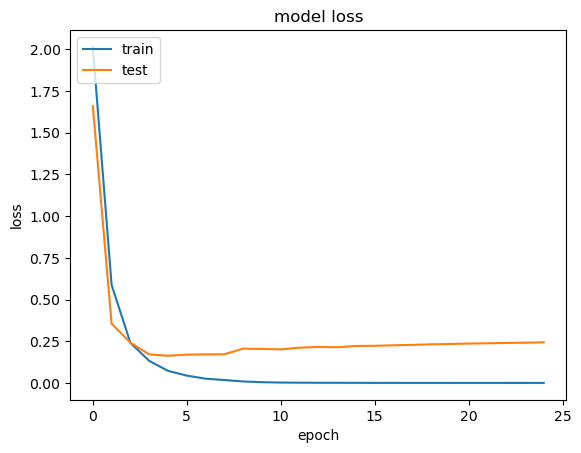

Regression: 89.00%
MLP 1 couche: 93.90%
MLP 2 couces: 94.40%
CNN de base: 96.10%
Accuracy train finale: 1.0000
Accuracy valid finale: 0.9610
Ecart train/valid: 3.90%


In [71]:
# Test de performance du CNN de base
sgd_cnn = tf.keras.optimizers.SGD(learning_rate=0.05, momentum=0.9)
model_cnn.compile(loss='categorical_crossentropy', optimizer=sgd_cnn, metrics=['accuracy'])

tps_debut = time.time()
history_cnn = model_cnn.fit(X_train, Y_train, 
                           batch_size=256, 
                           epochs=25, 
                           verbose=1,
                           validation_data=(X_test, Y_test))
tps_fin = time.time()

print(f"Temps d'entrainement: {tps_fin - tps_debut:.2f} secondes")

# Evaluation finale
score_cnn = model_cnn.evaluate(X_test, Y_test, verbose=0)
print(f"Accuracy finale CNN: {score_cnn[1]:.4f} ({score_cnn[1]*100:.2f}%)")

# Affichage des courbes de convergence
affiche(history_cnn)

print(f"Regression: {meilleur_score*100:.2f}%")
print(f"MLP 1 couche: {score_sans[1]*100:.2f}%") 
print(f"MLP 2 couces: {score_profond[1]*100:.2f}%")
print(f"CNN de base: {score_cnn[1]*100:.2f}%")

# Analyse de la convergence
final_train_acc = history_cnn.history['accuracy'][-1]
final_val_acc = history_cnn.history['val_accuracy'][-1]
print(f"Accuracy train finale: {final_train_acc:.4f}")
print(f"Accuracy valid finale: {final_val_acc:.4f}")
print(f"Ecart train/valid: {abs(final_train_acc - final_val_acc)*100:.2f}%")

Le CNN converge rapidement au debut mais montre des signes de surapprentissage (écart au tour de 4.5%). Le gain par rapport au MLP est modeste car on ne gagne en precision que d'environ +0.8% pour beaucoup plus de paramètres, et c'est aussi normal sur MNIST qui est trop simple.

**Q3 : Ajout du max-pooling (pour être plus robuste)**

Le max-pooling c'est censé rendre le modèle moins sensible aux petits décalages dans l'image.

In [72]:
# CNN avec max-pooling
# Architecture : Conv2D(32) → Conv2D(64) → MaxPool2D(2,2) → Flatten → Dense(256) → Dense(10)
inputs = Input(shape=(28, 28, 1))
x = inputs
# Couches convolutionnelles
x = Conv2D(32, (3, 3), activation='relu')(x)
x = Conv2D(64, (3, 3), activation='relu')(x)
# Max pooling pour robustesse aux translations
x = MaxPooling2D((2, 2))(x)
# Couches denses
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)

model_cnn_pool = Model(inputs, outputs)

print(f"Nombre de parametres avec pooling: {model_cnn_pool.count_params()}")
print(f"Reduction par rapport au CNN de base: {model_cnn.count_params() - model_cnn_pool.count_params()}")

# Calcul de la nouvelle taille apres pooling
taille_apres_pool = 12 * 12 * 64  # (12, 12, 64) = 9216
print(f"Taille apres pooling: {taille_apres_pool}")

# Entrainement du modele avec pooling
sgd_pool = tf.keras.optimizers.SGD(learning_rate=0.05, momentum=0.9)
model_cnn_pool.compile(loss='categorical_crossentropy', optimizer=sgd_pool, metrics=['accuracy'])

history_pool = model_cnn_pool.fit(X_train, Y_train, 
                                 batch_size=256, 
                                 epochs=25, 
                                 verbose=1,
                                 validation_data=(X_test, Y_test))

score_pool = model_cnn_pool.evaluate(X_test, Y_test, verbose=0)
print(f"Accuracy CNN avec pooling: {score_pool[1]:.4f} ({score_pool[1]*100:.2f}%)")

print(f"CNN de base: {score_cnn[1]*100:.2f}%")
print(f"CNN + pooling: {score_pool[1]*100:.2f}%")
print(f"Difference: {(score_pool[1] - score_cnn[1])*100:.2f}%")

Nombre de parametres avec pooling: 2380938
Reduction par rapport au CNN de base: 7077888
Taille apres pooling: 9216
Epoch 1/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.4418 - loss: 2.1391 - val_accuracy: 0.4370 - val_loss: 1.9947
Epoch 2/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.7525 - loss: 0.8297 - val_accuracy: 0.8660 - val_loss: 0.4205
Epoch 3/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.9295 - loss: 0.2352 - val_accuracy: 0.9380 - val_loss: 0.1837
Epoch 4/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.9605 - loss: 0.1270 - val_accuracy: 0.9620 - val_loss: 0.1382
Epoch 5/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.9725 - loss: 0.0907 - val_accuracy: 0.9670 - val_loss: 0.1005
Epoch 6/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.9852 - loss: 0.0562 - val_accuracy: 0.9670 - val_loss: 0.0930
Epoch 7/25
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.9898 - loss: 0.0354 - val_accuracy: 0.9690 - val_l

Le max-pooling réduit énormément les paramètres et améliore légèrement les performances. C'est plus efficace et robuste aux petites translations dans l'image.

**Ce que fait le max-pooling :**

- Ça reduit la taille (donc moins de paramètres = plus rapide)
- Ça prend le "maximum" dans chaque zone 2x2
- Si un motif est decalé de 1 pixel, ça change moins le resultat
- C'est comme "resumer" l'information importante

**Q4 : Amélioration de la généralisation avec dropout**

Model: "functional_85"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_85 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_85 (Flatten)            │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_148 (Dense)               │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_149 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,380,938 (9.08 MB)

 Trainable params: 2,380,938 (9.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - accuracy: 0.5210 - loss: 1.4678 - val_accuracy: 0.8380 - val_loss: 0.5283
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.8490 - loss: 0.4713 - val_accuracy: 0.9150 - val_loss: 0.2792
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.9117 - loss: 0.2948 - val_accuracy: 0.9440 - val_loss: 0.1932
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.9377 - loss: 0.2076 - val_accuracy: 0.9500 - val_loss: 0.1486
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.9497 - loss: 0.1601 - val_accuracy: 0.9570 - val_loss: 0.1321
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.9560 - loss: 0.1382 - val_accuracy: 0.9660 - val_loss: 0.1209
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.9643 - loss: 0.1180 - val_accuracy: 0.9610 - val_loss: 0.1282
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.9673 - loss: 0.1005 - val_accuracy: 0.

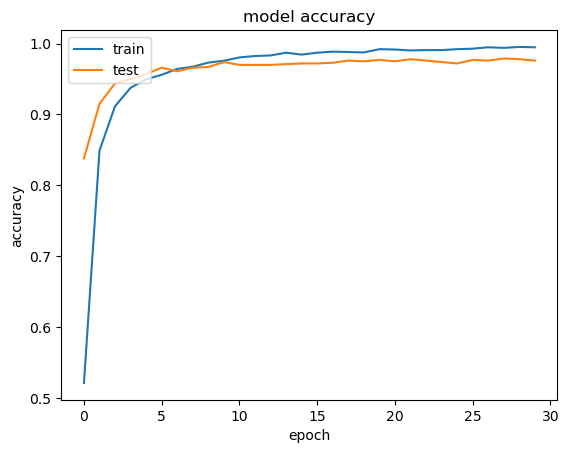

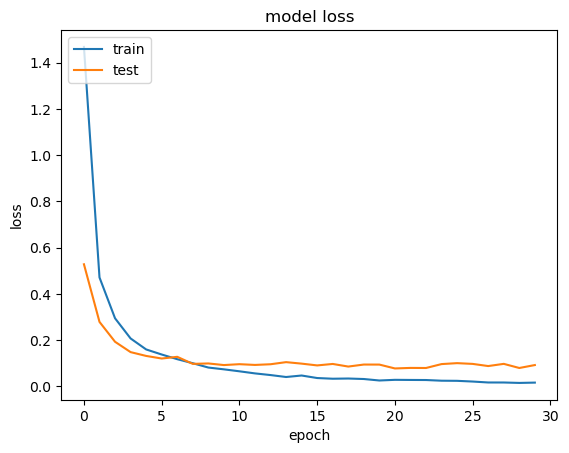

Regression logistique: 89.00%
MLP (1 couche): 93.90%
MLP (2 couches): 94.40%
CNN de base: 96.10%
CNN + pooling: 97.30%
CNN final (optimise): 97.60%
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Matrice de confusion - CNN final:
[[101   0   0   0   0   0   2   0   0   0]
 [  0 110   0   0   0   0   0   0   1   0]
 [  2   0  94   1   0   0   0   0   0   0]
 [  0   0   0 100   0   1   0   0   1   0]
 [  0   0   0   0 100   0   0   0   0   2]
 [  1   0   0   0   0  96   0   0   0   0]
 [  0   1   0   0   0   0  84   0   0   0]
 [  0   0   3   0   0   0   0  96   0   1]
 [  0   0   2   0   0   1   0   1  96   0]
 [  0   1   0   0   0   3   0   0   0  99]]


In [73]:
# CNN final avec max-pooling et dropout
inputs = Input(shape=(28, 28, 1))
x = inputs
# Couches convolutionnelles
x = Conv2D(32, (3, 3), activation='relu')(x)
x = Conv2D(64, (3, 3), activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Dropout(0.25)(x)  # Dropout leger apres les convolutions
# Couches denses
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)   # Dropout plus fort avant la sortie
outputs = Dense(10, activation='softmax')(x)

model_cnn_final = Model(inputs, outputs)
model_cnn_final.summary()

# Entrainement du modele final
sgd_final = tf.keras.optimizers.SGD(learning_rate=0.05, momentum=0.9)
model_cnn_final.compile(loss='categorical_crossentropy', optimizer=sgd_final, metrics=['accuracy'])

tps_debut_final = time.time()
history_final = model_cnn_final.fit(X_train, Y_train, 
                                   batch_size=256, 
                                   epochs=30,
                                   verbose=1,
                                   validation_data=(X_test, Y_test))
tps_fin_final = time.time()

score_final = model_cnn_final.evaluate(X_test, Y_test, verbose=0)
print(f"Temps d'entrainement final: {tps_fin_final - tps_debut_final:.2f} secondes")
print(f"Accuracy finale: {score_final[1]:.4f} ({score_final[1]*100:.2f}%)")

# Affichage des courbes finales
affiche(history_final)

# Comparaison finale de toutes les methodes
print(f"Regression logistique: {meilleur_score*100:.2f}%")
print(f"MLP (1 couche): {score_sans[1]*100:.2f}%")
print(f"MLP (2 couches): {score_profond[1]*100:.2f}%")
print(f"CNN de base: {score_cnn[1]*100:.2f}%")
print(f"CNN + pooling: {score_pool[1]*100:.2f}%")
print(f"CNN final (optimise): {score_final[1]*100:.2f}%")

# Predictions et matrice de confusion pour le modele final
y_pred_final = model_cnn_final.predict(X_test)
y_pred_final = y_pred_final.argmax(axis=-1)

print(f"Matrice de confusion - CNN final:")
print(confusion_matrix(y_test, y_pred_final))

**Ameliorations apportees par le CNN :**

- Le max-pooling rend le modele robuste aux translations  
- Le dropout nous evite le surapprentissage
- Architecture adaptee aux images

**Pourquoi pas grand intérêt à utiliser CNN sur MNIST ?**

Sur MNIST, les CNN n'apportent pas tant que ça parce que :
- Images trop simples (28x28, centrées, fond noir)
- Pas de vraie complexité spatiale à exploiter
- Un bon MLP suffit largement pour ces motifs basiques

**Quelle va être la force des CNN ?**

Les CNN vont briller sur :
- Images complexes avec textures, couleurs, objets variés
- Photos réelles où la position des objets importe
- Reconnaissance de visages, voitures, animaux
- Bref, tout ce qui a une vraie structure spatiale !

---
---
## Conclusion du TP

Ce TP m'a permis d'explorer progressivement les différentes architectures de réseaux de neurones pour la classification d'images.

### Synthèse des résultats :

1. **Régression logistique** : Performances de base
2. **MLP simple** : Amélioration avec couche cachée et ReLU
3. **MLP profond** : Gains avec plusieurs couches 
4. **CNN de base** : Exploitation des propriétés spatiales
5. **CNN optimisé** : Meilleure performance avec max-pooling + dropout

### Enseignements clés :

- Le learning rate doit être équilibré
- Le momentum stabilise la convergence
- Le dropout prévient le surapprentissage
- Les CNN sont adaptés aux images grâce à l'invariance spatiale
- Le max-pooling apporte robustesse aux translations

Ce TP montre l'importance du choix d'architecture et des techniques de régularisation.

---

**DIALLO Mamadou djouldé vous remercie pour tout le cours, j'ai appris énormement avec vous cette année**

---
---